<h2>The challenge</h2>
In today's data-driven world, valuable insights are locked away in spreadsheets and datasets that most professionals don't have the technical skills to analyze. Business owners, managers, and domain experts know their data is valuable but lack the programming knowledge to extract meaningful insights.

About this lab
In this lab, you will create an AI-powered agent that can help non-technical users perform data science tasks through natural language. You will:

Build a collection of LangChain tools that perform basic data science tasks:

Listing available datasets
Loading and analyzing CSV files
Generating dataset summaries and statistics
Training and evaluating machine learning models
Document each tool's purpose and output format clearly to ensure the AI agent can use them effectively

Demonstrate why regular conversational agents have limitations when working with structured data

Implement an executor agent that can manage a multi-step workflow for data analysis

By the end of this lab, you'll understand how to combine language models with specialized tools to create practical applications that make data science accessible to everyone.

<h2>Objectives</h2>

By the end of this project, you will be able to:

- Create specialized LangChain tools: Develop custom tools for performing key data science tasks like dataset discovery, analysis, and modeling.
- Implement efficient caching mechanisms: Build a system that stores and manages datasets in memory to optimize performance across multiple queries.
- Design a natural language interface: Connect a language model to your tools, enabling conversational access to data science capabilities.
- Develop context-aware agents: Create an executor agent that can maintain state and execute multi-step data analysis workflows.
- Handle errors gracefully: Implement robust error handling for file operations and data processing tasks.
- Test your assistant with real queries: Evaluate the system with practical business questions that demonstrate its ability to make data science accessible.

This project equips you with the skills to bridge the gap between non-technical users and data insights, democratizing access to advanced analytics through conversation.



<h2>Setup</h2>

For this lab, you will be using the following libraries:

- langchain for building modular AI applications with tools and agents.
- langchain-openai for connecting LangChain with OpenAI's language models.
- openai for accessing AI models that power your conversational interface.
- pandas for data manipulation and analysis of CSV datasets.
- numpy for numerical operations and array processing.
- scikit-learn for implementing machine learning models and evaluation metrics.
- matplotlib for creating data visualizations based on analysis results.
- seaborn for enhanced statistical visualizations of dataset patterns.

Installing required libraries
The following required libraries are not pre-installed in the Skills Network Labs environment. You must run the following cell to install them. This step could take several minutes; please be patient.

In [ ]:
# Pin a compatible LangChain 0.3.x stack; newer langchain-core releases removed
# the `is_data_content_block` symbol used by langchain-ollama.
%pip install langchain==0.3.21
# %pip install langchain-core==0.3.76
%pip install langchain-openai==0.3.10
%pip install langchain-ollama==0.3.10
%pip install langsmith==0.3.45
%pip install openai==1.68.2
%pip install pandas==2.2.3
%pip install numpy==2.2.4
%pip install matplotlib==3.10.1
%pip install seaborn==0.13.2
%pip install scikit-learn==1.6.1

In [2]:
# ! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/N0CceRlquaf9q85PK759WQ/regression-dataset.csv
# ! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/7J73m6Nsz-vmojwab91gMA/classification-dataset.csv
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/N0CceRlquaf9q85PK759WQ/regression-dataset.csv
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/7J73m6Nsz-vmojwab91gMA/classification-dataset.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  1.90M 100  1.90M   0      0  1.79M      0   00:01   00:01              0
100  1.90M 100  1.90M   0      0  1.79M      0   00:01   00:01              0
100  1.90M 100  1.90M   0      0  1.79M      0   00:01   00:01              0
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0           00:01              0
100 118.5k 100 118.5k   0      0  85734      0   00:01   00:01          99260
100 118.5k 100 118.5k   0      0  85718      0   00:01   00:01          99260
100 118.5k 100 118.5k   0      0  85703      0   00:01   00:01

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn
import sklearn
import langchain
import openai
import langchain_openai
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage

import glob
import os
from typing import List, Optional

os.environ["OPENAI_API_KEY"] = "your OpenAI API key here"


# Initialize the model with your local pulled version
llm = ChatOllama(
    model="llama3",
    temperature=0.7,
)


<h2>Langchain tools</h2>
Tools in LangChain are interfaces that allow an AI model (such as GPT-4) to interact with external systems, retrieve data, or perform actions beyond simple text generation. These tools act as APIs or function calls that the AI can invoke when needed.
<p>
First, you'll create a tool to identify available datasets in the local directory. This tool helps your agent discover what CSV files are available for analysis without requiring the user to explicitly specify filenames. The assumption is that the CSV files have descriptive names that indicate their content. This is typically the first step in your data analysis workflow: discovering what data is available before loading or analyzing anything.
<p>
LangChain tools are <u>simple Python functions wrapped with the @tool decorator</u> (imported from langchain_core.tools). They allow Large Language Models (LLMs) to call specific functions, enabling structured workflows and external tool integrations.

from langchain_core.tools import tool

@tool
def my_tool(input: <type>) -> <output_type>:
    """
    Short description of what the tool does.

    Args:
        input (<type>): Explanation of the input argument.

    Returns:
        <output_type>: Explanation of the returned value.
    """
    # implement your logic here
    return tool_output
The tool components:

- @tool Decorator: Marks the function as a tool, allowing LangChain to integrate it and expose it to the LLM.

- Input Arguments: The parameters your tool function accepts, along with type annotations for clarity.

- Tool Description: A clear, concise explanation used by LangChain and the LLM to understand when and how to call the tool.

- Return Type: Specifies the type of data your tool will return, improving clarity and reliability.

- .name: Automatically derived from your Python function name; used by LangChain to identify the tool.

- .description: Automatically extracted from your function's docstring; helps the LLM understand the tool’s purpose.

- .args: Represents input arguments with their associated types, allowing LangChain to validate and pass correct values to your tool function.

Let's create the first LangChain tool, which lists all CSV files in the current directory.

- os.getcwd() retrieves the current working directory.
- os.path.join(os.getcwd(), "*.csv") constructs a path pattern to match all CSV files (* matches all filenames ending with .csv).
- glob.glob(pattern) returns a list of files that match the given pattern.


In [49]:
from langchain_core.tools import tool
import json

@tool
def list_csv_files() -> str:
    """List all CSV file names in the local directory.

    Returns:
        A JSON string containing a list of CSV file names.
        If no CSV files are found, returns an empty list.
    """
    csv_files = glob.glob(os.path.join(os.getcwd(), "*.csv"))
    if not csv_files:
        return json.dumps([])
    return json.dumps([os.path.basename(file) for file in csv_files])

print("Tool Name:", list_csv_files.name)
print("Tool Description:", list_csv_files.description)
print("Tool Arguments:", list_csv_files.args)


result_temp_file_names = list_csv_files.invoke({})
print("Result:", result_temp_file_names)


Tool Name: list_csv_files
Tool Description: List all CSV file names in the local directory.

    Returns:
        A JSON string containing a list of CSV file names.
        If no CSV files are found, returns an empty list.
Tool Arguments: {}
Result: ["classification-dataset.csv", "regression-dataset.csv"]


<h2>Dataset caching tool</h2>
As you build more complex tools, you need to efficiently manage datasets in memory. Since language models communicate via text, sending entire datasets in each response would waste tokens and context window space. To solve this, you'll create a global cache that stores DataFrames after they're first loaded. This approach has several benefits:

Reduces token usage by referencing datasets by name rather than content
Improves performance by loading data only once
Maintains dataset availability between different tool calls
The following tool allows the agent to preload datasets into this cache system.

In [55]:
DATAFRAME_CACHE = {}
import json

@tool
def preload_datasets(paths_json: str) -> str:
    """
    Loads CSV files into a global cache if not already loaded.
    
    This function helps to efficiently manage datasets by loading them once
    and storing them in memory for future use. Without caching, you would
    waste tokens describing dataset contents repeatedly in agent responses.
    
    Args:
        paths_json: A JSON string containing a list of file paths to CSV files.

    Returns:
        A message summarizing which datasets were loaded or already cached.
    """
    print("Preloading datasets with paths_json:", paths_json)
    paths: List[str] = json.loads(paths_json)  # Convert JSON string to list of paths
    loaded = []
    cached = []
    for path in paths:
        if path not in DATAFRAME_CACHE:
            DATAFRAME_CACHE[path] = pd.read_csv(path)
            loaded.append(path)
        else:
            cached.append(path)
    
    return (
        f"Loaded datasets: {loaded}\n"
        f"Already cached: {cached}"
    )

preload_result = preload_datasets.invoke({"paths_json": result_temp_file_names})
print("Preload Result:", preload_result)

Preloading datasets with paths_json: ["classification-dataset.csv", "regression-dataset.csv"]
Preload Result: Loaded datasets: ['classification-dataset.csv', 'regression-dataset.csv']
Already cached: []


You may think that the global keyword would work effectively instead of DATAFRAME CACHE, but when using functions in Python with LangChain agents, simply writing the keyword global isn't enough to maintain data between different tool calls. This is because each time the agent runs a tool, it might do so in a separate execution environment, causing any global variables to reset. Instead, using a module-level dictionary (DATAFRAME_CACHE) that lives outside any function creates a persistent storage space that all tools can access without explicitly passing it around. This approach works reliably across multiple function calls, even when they happen in different contexts, and keeps the function interfaces clean by avoiding the need to pass the cache as an additional parameter to every tool.

Well-structured docstrings are essential for your LLM-based tools because they serve as instructions for the AI agent. The agent relies on these descriptions to understand when and how to use each tool. Similarly, formatted outputs help the agent parse and interpret results properly. Always ensure your tool functions have clear docstrings and return well-structured outputs that are easy for both humans and AI to understand.

<h2>Summarization tool</h2>
Next, create a tool to provide dataset summaries with key statistical information. This tool gives the agent a quick overview of each dataset without transferring the entire content. It examines the structure of each CSV file and returns metadata that helps the agent understand what kinds of data it's working with.

Type annotations are extremely important in the tools for several reasons:

They provide clear documentation of expected inputs and outputs
They enable static type checking to catch errors before runtime
Most critically, they help the AI agent understand exactly what data to provide and what format to expect in return
For this tool, nested type annotations (List[Dict[str, Any]]) precisely define the structured data that will be returned. This allows the agent to parse and utilize the results correctly in subsequent reasoning steps.




In [53]:
from typing import List, Optional,Dict,Any

@tool
def get_dataset_summaries(datasetpaths: str) -> List[Dict[str, Any]]:
    """
    Analyze multiple CSV files and return metadata summaries for each.

    Args:
        datasetpaths str: 
            A JSON string containing a list of file paths to CSV datasets.

    Returns:
        List[Dict[str, Any]]: 
            A list of summaries, one per dataset, each containing:
            - "file_name": The path of the dataset file.
            - "column_names": A list of column names in the dataset.
            - "data_types": A dictionary mapping column names to their data types (as strings).
    """
    summaries = []
    dataset_paths: List[str] = json.loads(datasetpaths)  # Convert JSON string to list of paths

    for path in dataset_paths:
        # Load and cache the dataset if not already cached
        if path not in DATAFRAME_CACHE:
            DATAFRAME_CACHE[path] = pd.read_csv(path)
        
        df = DATAFRAME_CACHE[path]

        # Build summary
        summary = {
            "file_name": path,
            "column_names": df.columns.tolist(),
            "data_types": df.dtypes.astype(str).to_dict()
        }

        summaries.append(summary)

    return summaries

get_dataset_summaries_result = get_dataset_summaries.invoke({"datasetpaths": result_temp_file_names})
print("Dataset Summaries:", get_dataset_summaries_result)

Dataset Summaries: [{'file_name': 'classification-dataset.csv', 'column_names': ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target'], 'data_types': {'mean radius': 'float64', 'mean texture': 'float64', 'mean perimeter': 'float64', 'mean area': 'float64', 'mean smoothness': 'float64', 'mean compactness': 'float64', 'mean concavity': 'float64', 'mean concave points': 'float64', 'mean symmetry': 'float64', 'mean fractal dimension': 'float64', 'radius error': 'float6

<h2>DataFrame method execution tool</h2>
Now that you have a basic understanding of your datasets, you need a flexible way to explore and analyze them. Just like data scientists use various pandas DataFrame methods (head(), describe(), info(), etc.), your agent needs the ability to apply these methods to your cached datasets.

You'll leverage Python's getattr() function, which allows you to retrieve and call a method using its string name. This approach gives your agent the flexibility to select the most appropriate DataFrame method based on the current analysis needs.

By providing both the file name and the method name as parameters, the LLM can intelligently choose which analysis techniques to apply to different datasets. The result of each method call is converted to a string representation, making it accessible to the LLM for further analysis and reasoning.

In [7]:
@tool
def call_dataframe_method(file_name: str, method: str) -> str:
   """
   Execute a method on a DataFrame and return the result.
   This tool lets you run simple DataFrame methods like 'head', 'tail', or 'describe' 
   on a dataset that has already been loaded and cached using 'preload_datasets'.
   Args:
       file_name (str): The path or name of the dataset in the global cache.
       method (str): The name of the method to call on the DataFrame. Only no-argument 
                     methods are supported (e.g., 'head', 'describe', 'info').
   Returns:
       str: The output of the method as a formatted string, or an error message if 
            the dataset is not found or the method is invalid.
   Example:
       call_dataframe_method(file_name="data.csv", method="head")
   """
   # Try to get the DataFrame from cache, or load it if not already cached
   if file_name not in DATAFRAME_CACHE:
       try:
           DATAFRAME_CACHE[file_name] = pd.read_csv(file_name)
       except FileNotFoundError:
           return f"DataFrame '{file_name}' not found in cache or on disk."
       except Exception as e:
           return f"Error loading '{file_name}': {str(e)}"
   
   df = DATAFRAME_CACHE[file_name]
   func = getattr(df, method, None)
   if not callable(func):
       return f"'{method}' is not a valid method of DataFrame."
   try:
       result = func()
       return str(result)
   except Exception as e:
       return f"Error calling '{method}' on '{file_name}': {str(e)}"

These tools provide specialized functionality for building and evaluating machine learning models on datasets. The agent will first analyze the dataset structure using previous tools to determine if the prediction task is classification or regression. Then, based on its assessment, it will call either evaluate_classification_dataset or evaluate_regression_dataset, providing the appropriate dataset filename and target column. Both tools handle the technical aspects of machine learning (splitting the data, training the model, and calculating performance metrics) while abstracting away implementation details. For classification tasks, the agent will examine the target column's data type and unique values to determine if it's categorical, then call the classification evaluator, which returns accuracy metrics. For regression tasks involving continuous numerical predictions, the agent will select the regression evaluator that returns the R² score and mean squared error. This decision-making process showcases how a well-designed agent can choose the appropriate tool based on data characteristics, demonstrating intelligent workflow automation.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

# Assumes this global cache is shared
DATAFRAME_CACHE = {}

@tool
def evaluate_classification_dataset(file_name: str, target_column: str) -> Dict[str, float] | Dict[str, str]:
    """
    Train and evaluate a classifier on a dataset using the specified target column.
    Args:
        file_name (str): The name or path of the dataset stored in DATAFRAME_CACHE.
        target_column (str): The name of the column to use as the classification target.
    Returns:
        Dict[str, float]: A dictionary with the model's accuracy score.
    """
    print(f"Evaluating classification dataset: {file_name} with target column: {target_column}")
    # Try to get the DataFrame from cache, or load it if not already cached
    if file_name not in DATAFRAME_CACHE:
        try:
            DATAFRAME_CACHE[file_name] = pd.read_csv(file_name)
        except FileNotFoundError:
            return {"error": f"DataFrame '{file_name}' not found in cache or on disk."}
        except Exception as e:
            return {"error": f"Error loading '{file_name}': {str(e)}"}
    
    df = DATAFRAME_CACHE[file_name]
    if target_column not in df.columns:
        return {"error": f"Target column '{target_column}' not found in '{file_name}'."}
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return {"accuracy": acc}

@tool
def evaluate_regression_dataset(file_name: str, target_column: str) -> Dict[str, float]:
    """
    Train and evaluate a regression model on a dataset using the specified target column.
    Args:
        file_name (str): The name or path of the dataset stored in DATAFRAME_CACHE.
        target_column (str): The name of the column to use as the regression target.
    Returns:
        Dict[str, float]: A dictionary with R² score and Mean Squared Error.
    """
    # Try to get the DataFrame from cache, or load it if not already cached
    if file_name not in DATAFRAME_CACHE:
        try:
            DATAFRAME_CACHE[file_name] = pd.read_csv(file_name)
        except FileNotFoundError:
            return {"error": f"DataFrame '{file_name}' not found in cache or on disk."}
        except Exception as e:
            return {"error": f"Error loading '{file_name}': {str(e)}"}
    
    df = DATAFRAME_CACHE[file_name]
    if target_column not in df.columns:
        return {"error": f"Target column '{target_column}' not found in '{file_name}'."}
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return {
        "r2_score": r2,
        "mean_squared_error": mse
    }


evaluation_cl_response = evaluate_classification_dataset.invoke({"file_name": "classification-dataset.csv", "target_column": "target"})
# evaluation_cl_response = evaluate_classification_dataset.invoke( "classification-dataset.csv","target")
print("Classification Evaluation Result:", evaluation_cl_response)
evaluation_rg_response = evaluate_regression_dataset.invoke({"file_name": "regression-dataset.csv", "target_column": "target"})
print("Regression Evaluation Result:", evaluation_rg_response)

Evaluating classification dataset: classification-dataset.csv with target column: target
Classification Evaluation Result: {'accuracy': 0.9649122807017544}
Regression Evaluation Result: {'r2_score': 0.818654834178601, 'mean_squared_error': 0.23763633345294596}


<h2>Agents</h2>
Agents in LangChain are advanced components that enable AI models to decide when and how to use tools dynamically. Instead of relying on predefined scripts, agents analyze user queries and choose the best tools to achieve a goal. The next step is defining your agent, which requires specifying how it should think and behave. You'll use ChatPromptTemplate.from_messages() to create a structured prompt with three essential components:

System message: This establishes the agent's identity and primary objective. You define it as a data science assistant whose task is to analyze CSV files and determine whether each dataset is suitable for classification or regression based on its structure. This gives the agent a clear purpose and scope.

User input: The {input} placeholder will be replaced with the user's actual query. This allows the agent to respond directly to what the user is asking about.

Agent scratchpad: The {agent_scratchpad} placeholder is crucial for tool-calling agents as it provides space for the agent to show its reasoning process and track intermediate steps. This enables the agent to build a chain of thought, call tools sequentially, and use the results from one tool to inform decisions about subsequent tool calls.

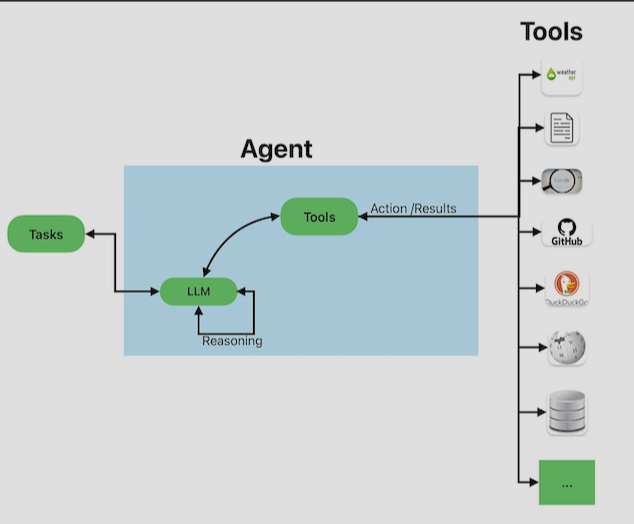



In [67]:
from langchain_openai import ChatOpenAI
from langchain.agents import tool, create_openai_tools_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 🧠 Step 2: Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", 
     """You are a data science assistant. Use the available tools to analyze CSV files. 
     Your job is to determine whether each dataset is for classification or regression, based on its structure. You have access to the following tools: {tool_names}.\n\n{tools}

    Use the following format:

    Question: the input question you must answer
    Thought: you should always think about what to do
    Action: the action to take, should be one of [{tool_names}]
    Action Input: the input to the action
    Observation: the result of the action
    ... (this Thought/Action/Action Input/Observation can repeat N times)
    Thought: I now know the final answer
    Final Answer: the final answer to the original input question
     """
     ),
    
    ("human", "{input}\n{agent_scratchpad}")
])

In [75]:
#create a agent with required tools
from langchain.agents import AgentExecutor, create_react_agent

tools=[list_csv_files, preload_datasets, get_dataset_summaries, call_dataframe_method, evaluate_classification_dataset, evaluate_regression_dataset]

llm.bind_tools(tools)

### Agent creation and limitations

# Here, you'll create your agent using `create_openai_tools_agent()`, which combines the language model, tools, and prompt template into a functional agent. However, this raw agent has significant limitations when used directly. It only performs a single step of reasoning and tool usage per invocation, then returns its intermediate thought process rather than a final answer. This behavior occurs because the agent doesn't automatically manage the full loop of thinking, acting, observing results, and continuing to reason until reaching a complete solution.

# 3. Define the mandatory ReAct prompt template
# The template MUST include: 'tools', 'tool_names', 'input', and 'agent_scratchpad'

# Construct the tool calling agent
agent = create_react_agent(llm, tools, prompt)

# 5. Create the executor by combining the agent and tools
agent_executor = AgentExecutor(
    agent=agent, tools=tools, verbose=True, handle_parsing_errors=True,
    max_iterations=10,  # Stops the agent after exactly 10 steps
    return_intermediate_steps=True  # <-- Enables step tracking. Configure the AgentExecutor to automatically pass formatting errors back to the model so it can fix its own mistake and try again.
)

# 6. Run the agent
response = agent_executor.invoke({"input": "Can you tell me about the dataset?"})
# response = agent_executor.invoke({
#     "input": "Can you tell me about the dataset?",
#     "intermediate_steps": []
# })



> Entering new AgentExecutor chain...
Let me check the available datasets for you!

First, I'll list all the CSV file names in the local directory using the `list_csv_files` action.

Action: list_csv_files
Action Input: None["classification-dataset.csv", "regression-dataset.csv"]I've listed the CSV file names in the local directory. It seems we have two datasets: "classification-dataset.csv" and "regression-dataset.csv". Now, I'd like to analyze the datasets to determine whether they're for classification or regression.

Action: preload_datasets
Action Input: ["classification-dataset.csv", "regression-dataset.csv"]Preloading datasets with paths_json: ["classification-dataset.csv", "regression-dataset.csv"]
Loaded datasets: []
Already cached: ['classification-dataset.csv', 'regression-dataset.csv']It seems that we've preloaded the datasets, and since they were already cached, nothing was actually loaded. Now, let's analyze the datasets to determine whether they're for classification o

In [76]:
# Get the first ToolAgentAction from the list
print(response)
print("Intermediate Steps:", response['intermediate_steps'])

# Print the key details
for step in response["intermediate_steps"]:
  agent_action, observation = step
  print(f"Tool Used: {agent_action.tool}")
  print(f"Tool Input: {agent_action.tool_input}")
  print(f"Observation: {observation}")
  print("-" * 40)

{'input': 'Can you tell me about the dataset?', 'output': 'The final answer to the original input question is that the datasets are for classification and regression, respectively.', 'intermediate_steps': [(AgentAction(tool='list_csv_files', tool_input='None', log="Let me check the available datasets for you!\n\nFirst, I'll list all the CSV file names in the local directory using the `list_csv_files` action.\n\nAction: list_csv_files\nAction Input: None"), '["classification-dataset.csv", "regression-dataset.csv"]'), (AgentAction(tool='preload_datasets', tool_input='["classification-dataset.csv", "regression-dataset.csv"]', log='I\'ve listed the CSV file names in the local directory. It seems we have two datasets: "classification-dataset.csv" and "regression-dataset.csv". Now, I\'d like to analyze the datasets to determine whether they\'re for classification or regression.\n\nAction: preload_datasets\nAction Input: ["classification-dataset.csv", "regression-dataset.csv"]'), "Loaded data

In [ ]:
print("📊 Ask questions about your dataset (type 'exit' to quit):")

while True:
    user_input=input(" You:")
    if user_input.strip().lower() in ['exit','quit']:
        print("see ya later")
        break
        
    result=agent_executor.invoke({"input":user_input})
    print(f"my Agent: {result['output']}")

    # The input prompt at the very top center of the VS Code window, rather than inside the notebook cell itself.When you run a cell containing input(), VS Code pauses execution and opens a small dropdown text box at the top of the editor layout
    

📊 Ask questions about your dataset (type 'exit' to quit):
